In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [14]:
PROC = Path("data/processed")

In [15]:
from pathlib import Path
PROC = Path("../data/processed")   # go up one level from /notebooks
summary = pd.read_csv(PROC / "supply_chain_summary.csv")



In [16]:
display(summary.head())
print("\nSummary stats:")
print(summary.describe())

,warehouse_id,sku_id,inventory_turnover,stockout_rate,mean_lead_time,lead_time_variance,fill_rate
0,WH_A,SKU0001,0.881416,0.883333,2.918367,1.754004,0.861789
1,WH_A,SKU0002,0.751872,0.866667,2.871795,1.719539,0.929825
2,WH_A,SKU0003,0.542053,0.783333,3.891892,1.882430,1.000000
3,WH_A,SKU0004,0.632438,0.766667,2.975000,1.832576,0.842975
4,WH_A,SKU0005,0.942069,0.866667,2.886364,1.807168,0.827586



Summary stats:
       inventory_turnover  stockout_rate  mean_lead_time  lead_time_variance  \
count          300.000000     300.000000      300.000000          300.000000   
mean             0.882598       0.839444        3.191531            1.807346   
std              0.290212       0.049558        0.265934            0.208763   
min              0.260762       0.683333        2.343750            1.153099   
25%              0.669265       0.800000        3.017045            1.663013   
50%              0.845303       0.833333        3.189422            1.796817   
75%              1.076338       0.870833        3.371595            1.929103   
max              1.866620       0.950000        3.944444            2.570233   

        fill_rate  
count  300.000000  
mean     0.872481  
std      0.059954  
min      0.704225  
25%      0.831877  
50%      0.875000  
75%      0.912281  
max      1.000000  


In [17]:
sns.set(style="whitegrid", context="talk", palette="Set2")

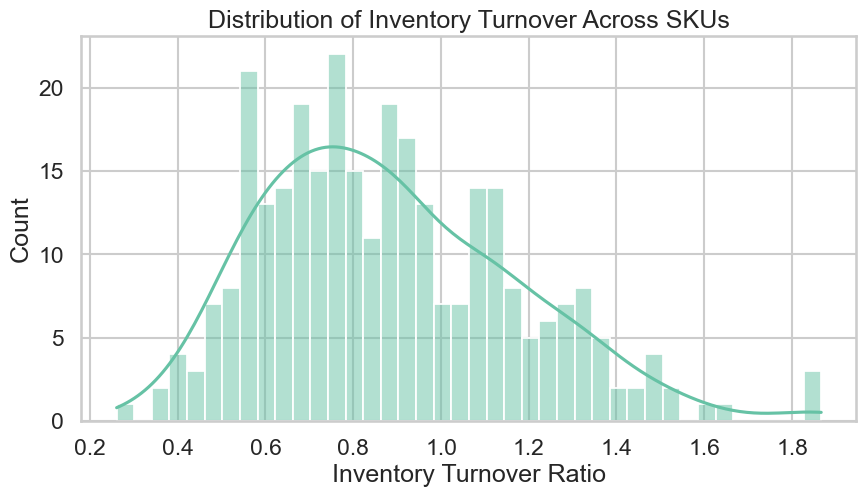

In [18]:
plt.figure(figsize=(10,5))
sns.histplot(summary["inventory_turnover"], bins=40, kde=True)
plt.title("Distribution of Inventory Turnover Across SKUs")
plt.xlabel("Inventory Turnover Ratio")
plt.ylabel("Count")
plt.show()


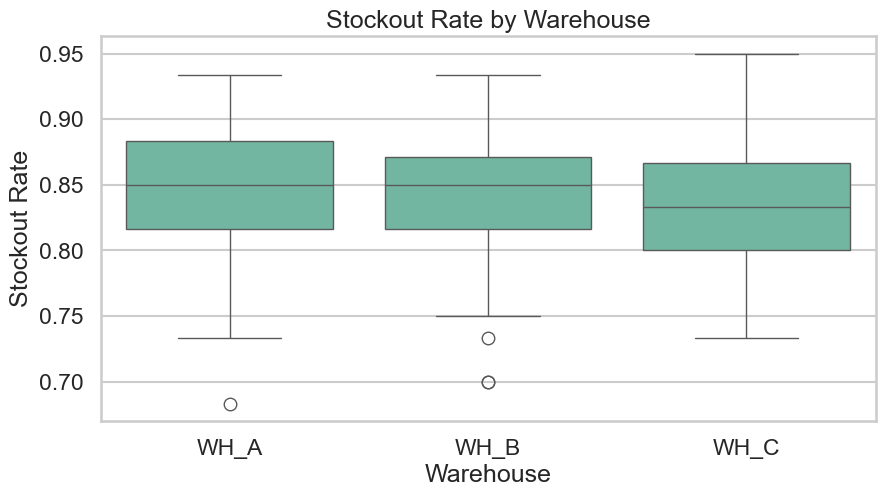

In [19]:
plt.figure(figsize=(10,5))
sns.boxplot(x="warehouse_id", y="stockout_rate", data=summary)
plt.title("Stockout Rate by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Stockout Rate")
plt.show()

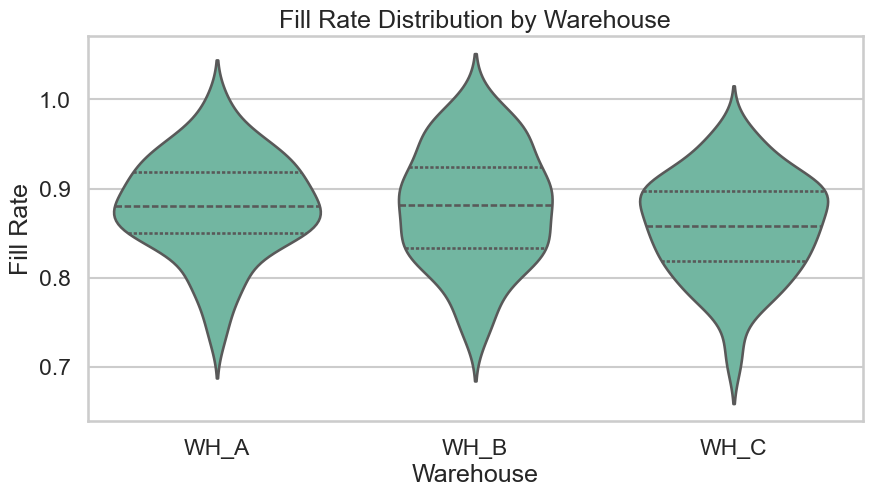

In [20]:
plt.figure(figsize=(10,5))
sns.violinplot(x="warehouse_id", y="fill_rate", data=summary, inner="quartile")
plt.title("Fill Rate Distribution by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Fill Rate")
plt.show()

C:\Users\shett\AppData\Local\Temp\ipykernel_30060\734196204.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x="warehouse_id", y="lead_time_variance", data=summary, ci=None)


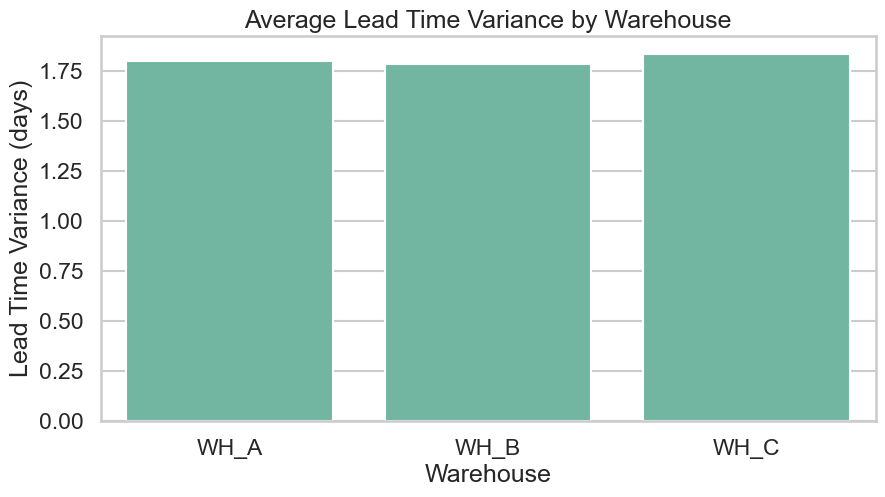

In [21]:
plt.figure(figsize=(10,5))
sns.barplot(x="warehouse_id", y="lead_time_variance", data=summary, ci=None)
plt.title("Average Lead Time Variance by Warehouse")
plt.xlabel("Warehouse")
plt.ylabel("Lead Time Variance (days)")
plt.show()

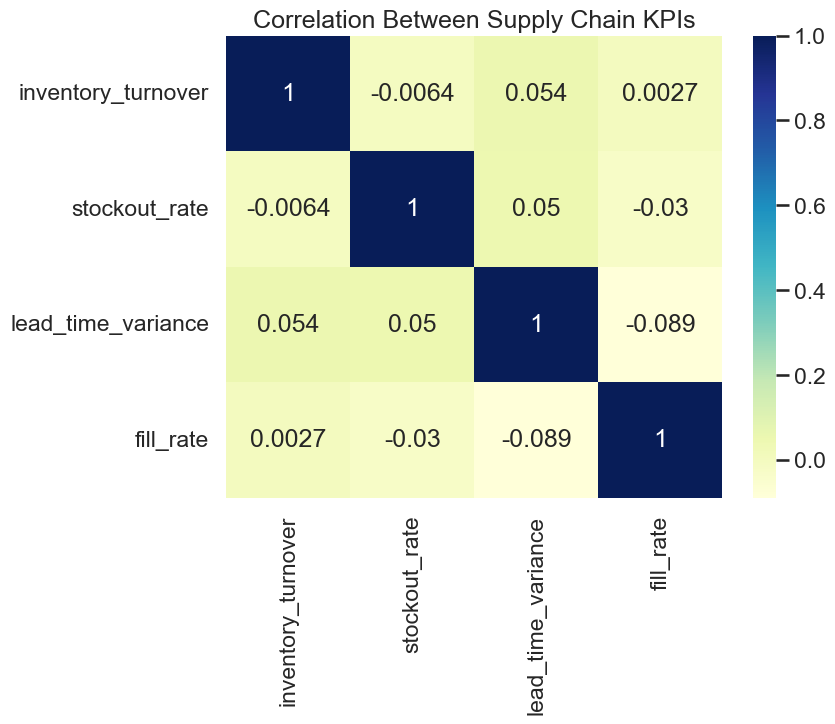

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(summary[['inventory_turnover', 'stockout_rate', 'lead_time_variance', 'fill_rate']].corr(),
            annot=True, cmap="YlGnBu")
plt.title("Correlation Between Supply Chain KPIs")
plt.show()

In [23]:
top_fill = summary.nlargest(10, 'fill_rate')[['warehouse_id', 'sku_id', 'fill_rate']]
low_turnover = summary.nsmallest(10, 'inventory_turnover')[['warehouse_id', 'sku_id', 'inventory_turnover']]

In [24]:
print("\nTop 10 SKUs by Fill Rate:")
display(top_fill)


Top 10 SKUs by Fill Rate:


,warehouse_id,sku_id,fill_rate
2,WH_A,SKU0003,1.000000
10,WH_A,SKU0011,1.000000
107,WH_B,SKU0008,1.000000
132,WH_B,SKU0033,1.000000
104,WH_B,SKU0005,0.985915
56,WH_A,SKU0057,0.980583
131,WH_B,SKU0032,0.980392
142,WH_B,SKU0043,0.980392
192,WH_B,SKU0093,0.978495
184,WH_B,SKU0085,0.975610


In [25]:
print("\nBottom 10 SKUs by Inventory Turnover:")
display(low_turnover)


Bottom 10 SKUs by Inventory Turnover:


,warehouse_id,sku_id,inventory_turnover
107,WH_B,SKU0008,0.260762
59,WH_A,SKU0060,0.355088
289,WH_C,SKU0090,0.362271
75,WH_A,SKU0076,0.396297
181,WH_B,SKU0082,0.398772
106,WH_B,SKU0007,0.409785
9,WH_A,SKU0010,0.411557
278,WH_C,SKU0079,0.425197
134,WH_B,SKU0035,0.431822
250,WH_C,SKU0051,0.433493
